In [2]:
# Import all necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


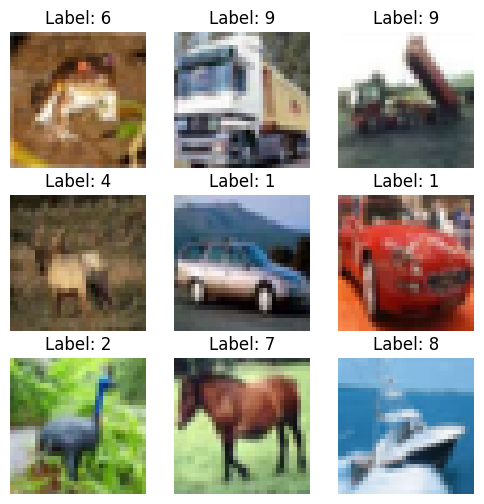

In [3]:
# Load CIFAR10 dataset (10 image classes)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values
train_images, test_images = train_images / 255.0, test_images / 255.0

# Show example images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i])
    plt.title(f"Label: {train_labels[i][0]}")
    plt.axis("off")
plt.show()


In [4]:
# Load pretrained ResNet50 without top classification layer
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',    # Pretrained on ImageNet
    include_top=False,     # Exclude original classifier
    input_shape=(32, 32, 3)
)

# Freeze base model so pretrained weights aren’t destroyed
base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')  # 10 classes for CIFAR10
])


In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train briefly for demo (increase epochs for better results)
history = model.fit(train_images, train_labels, epochs=3,
                    validation_data=(test_images, test_labels))


Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 341s 211ms/step - accuracy: 0.1494 - loss: 2.2791 - val_accuracy: 0.2369 - val_loss: 2.0592
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 329s 211ms/step - accuracy: 0.2058 - loss: 2.0996 - val_accuracy: 0.2825 - val_loss: 1.9519
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 291s 186ms/step - accuracy: 0.2124 - loss: 2.0701 - val_accuracy: 0.3086 - val_loss: 1.9366


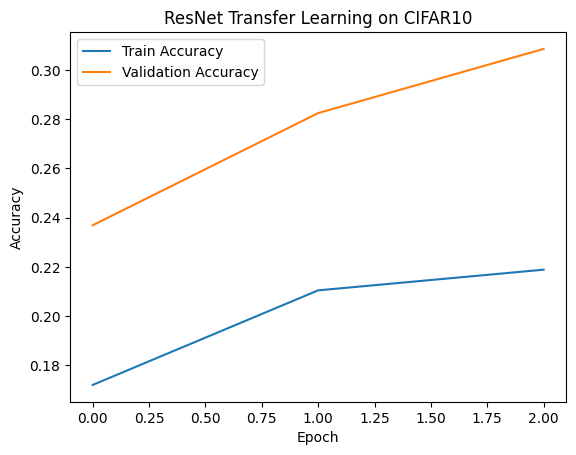

In [7]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet Transfer Learning on CIFAR10')
plt.legend()
plt.show()


313/313 - 46s - 146ms/step - accuracy: 0.3086 - loss: 1.9366

✅ Test accuracy: 30.86%
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


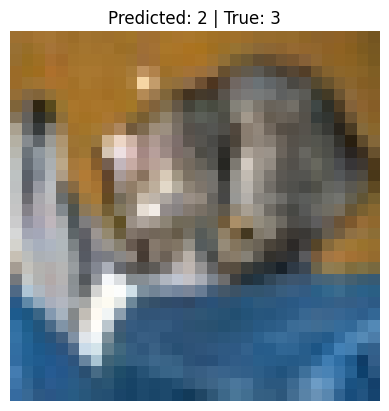

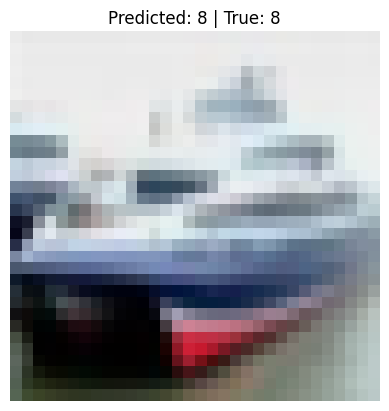

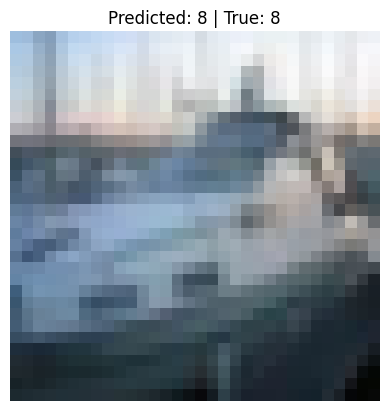

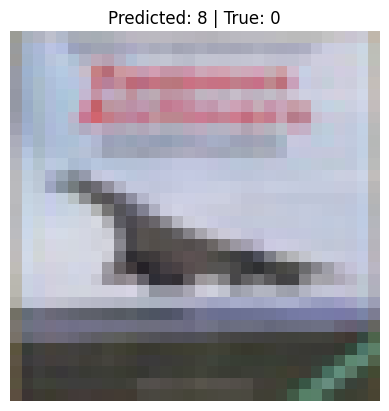

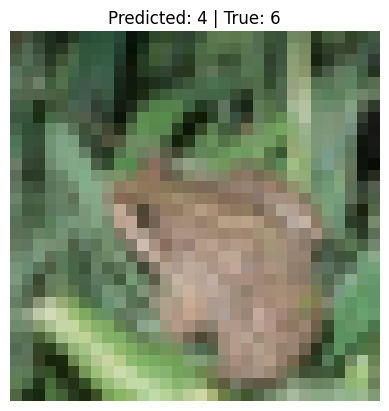

In [8]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\n✅ Test accuracy: {test_acc*100:.2f}%")

# Predict first 5 images
predictions = model.predict(test_images[:5])

for i in range(5):
    plt.imshow(test_images[i])
    plt.title(f"Predicted: {predictions[i].argmax()} | True: {test_labels[i][0]}")
    plt.axis("off")
    plt.show()
